# TODO 20.4.

- MAR assumption: generating coverage from the mag. field
    - repeat analysis with coverage masked data

- Minmax scaling

In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from sklearn.impute import KNNImputer
from numpy.lib.stride_tricks import sliding_window_view
from IPython.display import clear_output

from aipad.padimputer import PADImputer
from aipad.spacecrafts import SoloConstants, WindConstants
from aipad.datahandler import WindDataHandler
from aipad.pad_imputation import (
    make_train_test, pad_histogram, target_from_prediction)

In [2]:
bins = 8
time_avg_min = 1
avg_bin = f"{time_avg_min}min_{bins}bins"

file_path = Path("./data/hdf5") / f"wind_{avg_bin}.h5"
cov_path = Path("./data/coverages") / avg_bin
plot_path = Path(f"./plots/")

plot_path.mkdir(exist_ok=True)

solo = SoloConstants()
wind = WindConstants()

### Simple imputation strategies: row/column mean, average of forward and backward fill, linear interpolation, KNN without train-test split


In [3]:
results_path = Path(".") / "minmax_scaled_results"
results_path.mkdir(exist_ok=True)

imputer = PADImputer(wind)

miss_pcts = np.arange(10, 81, 10)

events = pd.read_csv("events.csv")
for event_no in range(len(events)):
    event_key = events.values[event_no][0]
    if event_key.split("-")[0] > "20120930":
        break
    for method, axis, miss_pct in product(["fill_average", "interp"], ["time", "pitch_angle"], miss_pcts):
        imputer.axis = 0 if axis == "time" else 1
        imputer.method = method
        imputer.run_analysis(event_key, miss_pct, repeats=50, scale="min_max",
                             fname=f"{event_key}_{imputer.method}_axis{imputer.axis}_{miss_pct}pct",
                             file_path=file_path, results_path=results_path,
                             show_plot=False, save_plot=False)
    clear_output()

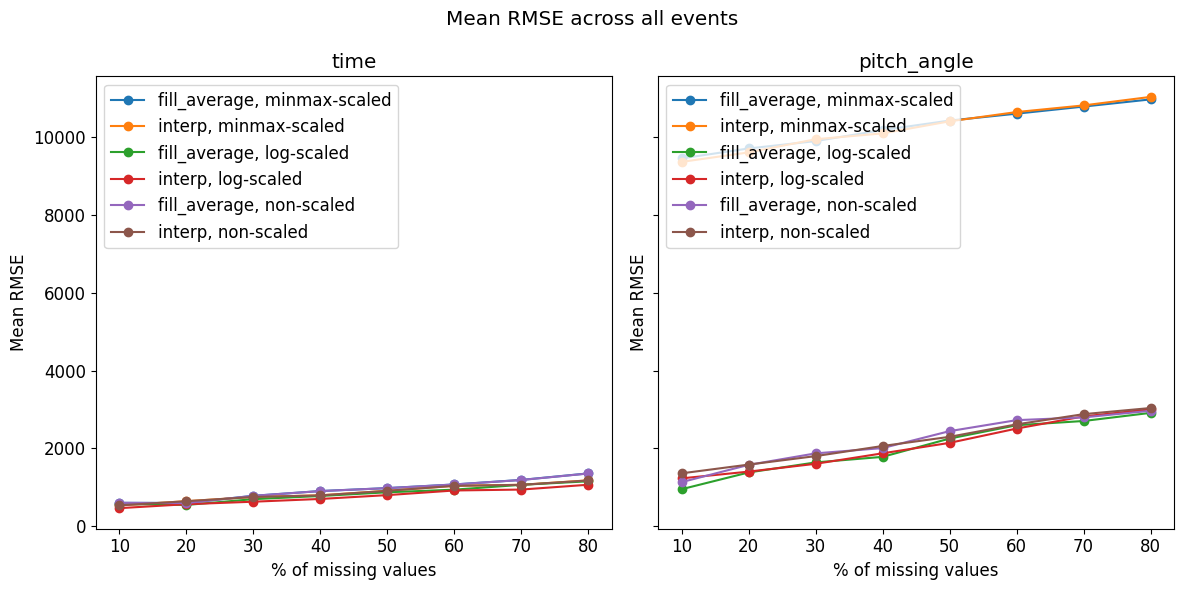

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os

row_vars = ["time", "pitch_angle"]
col_vars = ["fill_average", "interp"]
fig, axs = plt.subplots(ncols=2, figsize=(12, 6), sharex=True, sharey=True)
fig.suptitle("Mean RMSE across all events")

for scale in ["minmax", "log", "non"]:
    results_path = Path(f"/home/ojsant/gradu/{scale}_scaled_results")
    means = pd.read_csv(f"/home/ojsant/gradu/{scale}_scaled_results/20120728-220737.csv", header=[0, 1], index_col=[0, 1])["rmse_mean"]
    stds = pd.read_csv(f"/home/ojsant/gradu/{scale}_scaled_results/20120728-220737.csv", header=[0, 1], index_col=[0, 1])["rmse_std"]
    #base_arr = np.zeros((8,4))
    dfs_mean = []
    dfs_std = []
    for i, csv in enumerate(os.listdir(results_path)):
        dfs_mean.append(pd.read_csv(results_path / csv, header=[0, 1], index_col=[0, 1])["rmse_mean"].to_numpy())
        dfs_std.append(pd.read_csv(results_path / csv, header=[0, 1], index_col=[0, 1])["rmse_std"].to_numpy())

    means.iloc[:] = np.nanmean(np.stack(dfs_mean), axis=0)
    #stds.iloc[:] = np.nanmean(np.stack(dfs_std), axis=0)

    pcts = means.columns.astype(int)
    # Plot data
    for i, axis in enumerate(row_vars):
        for method in col_vars:
            axs[i].errorbar(pcts, means.loc[(method, axis)].values, yerr=None, fmt="o-", capsize=5, label=f"{method}, {scale}-scaled")
        axs[i].set_title(axis)
        axs[i].legend(loc="upper left")
        axs[i].set_xlabel(r"% of missing values")
        axs[i].set_ylabel("Mean RMSE")

plt.tight_layout()
plt.show()

In [7]:
means

miss_percent                       10           20           50           80
method       axis                                                           
mean         time         3692.976521  3730.494788  3888.736752  3991.436310
             pitch_angle  2407.177928  2448.920658  2788.398070  3067.650205
fill_average time          506.432205   674.781572   884.834853  1266.804028
             pitch_angle  1116.443538  1600.408793  2390.727702  2985.623926
interp       time          715.785867   555.204030   936.324184  1129.791928
             pitch_angle  1207.903137  1536.340768  2279.179908  2897.480531
knn          time          895.153573  1364.804047  1869.723454  2174.275594
             pitch_angle  2149.783500  2316.379922  2827.288760  3088.528302

### KNN with vs. without training

In [3]:
import subprocess
miss_pcts = [10, 20, 30, 40, 50, 60, 70, 80]
for n_neighbors in [1, 5, 15, 20]:
    for miss_pct in miss_pcts:
        rc = subprocess.run(("python3", "knn_train_test_analysis.py", str(miss_pct), str(n_neighbors), "min_max", str(123)))

['knn_train_test_analysis.py', '10', '1', 'min_max', '123']
Event 20120102-153731
Event 20120102-153731 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 37.942
RMSE std: 13.780
Event 20120127-183733
Event 20120127-183733 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 1252.161
RMSE std: 198.387
Event 20120313-170741
Event 20120313-170741 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 7053.022
RMSE std: 3700.367
Event 20120405-010733
Event 20120405-010733 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 84.846
RMSE std: 63.990
Event 20120411-055234
Event 20120411-055234 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 75.739
RMSE std: 10.498
Event 20120423-230730
Event 20120423-230730 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 20.831
RMSE std: 1.265
Event 20120517-005247
Event 201205

/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hi

Event 20120608-052241 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 29.270
RMSE std: 0.914
Event 20120702-185236
Event 20120702-185236 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 56.980
RMSE std: 3.426
Event 20120705-225234
Event 20120705-225234 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 114.314
RMSE std: 11.606
Event 20120712-165241
Event 20120712-165241 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 837.685
RMSE std: 159.246
Event 20120728-220737
Event 20120728-220737 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 92.589
RMSE std: 4.835
Event 20120901-065235
Event 20120901-065235 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 479.185
RMSE std: 172.036
Event 20120926-000918
Event 20120926-000918 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE 

/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hi

Event 20121214-042354 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 106.666
RMSE std: 101.765
Event 20130119-040738
Event 20130119-040738 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 269.703
RMSE std: 58.675
Event 20130206-235234
Event 20130206-235234 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 35.430
RMSE std: 1.554
Event 20130227-032239
Event 20130227-032239 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 54.269
RMSE std: 3.569
Event 20130316-223730
Event 20130316-223730 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 10127.579
RMSE std: 19241.611
Event 20130421-083000
Event 20130421-083000 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 155.697
RMSE std: 28.747
Event 20130502-053731


...

Event 20140104-183731 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 217.745
RMSE std: 14.366
Event 20140120-230740
Event 20140120-230740 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 296.492
RMSE std: 7.623
Event 20140214-085239
Event 20140214-085239 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 204.587
RMSE std: 14.029
Event 20140219-080000
Event 20140219-080000 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 1532.318
RMSE std: 86.699
Event 20140315-132237
Event 20140315-132237 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 108.566
RMSE std: 9.404
Event 20140417-213731
Event 20140417-213731 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 29.930
RMSE std: 0.971
Event 20140522-065238


/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hi

Event 20140522-065238 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 86.778
RMSE std: 3.289
Event 20140616-022231
Event 20140616-022231 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 48.695
RMSE std: 1.881
Event 20140825-155235
Event 20140825-155235 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 176.436
RMSE std: 8.909
Event 20140922-060000


/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts
/home/ojsant/gradu/aipad/pad_imputation.py:75: RuntimeWarning: divide by zero encountered in divide
  hist = hist / hist_counts


Event 20140922-060000 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 63.877
RMSE std: 4.967
Event 20141020-093740
Event 20141020-093740 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 32.581
RMSE std: 0.561
Event 20141205-230731
Event 20141205-230731 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 65.947
RMSE std: 2.098
Event 20141213-143737
Event 20141213-143737 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 83.415
RMSE std: 4.977
Event 20141223-083739
Event 20141223-083739 with 80 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 8039.339
RMSE std: 752.883


In [26]:
import pandas as pd
events = pd.read_csv("/home/ojsant/gradu/events.csv", header=0).values.ravel()
len(events) // 3

55

/tmp/ipykernel_20306/3528216789.py:18: RuntimeWarning: Mean of empty slice
  mean_rmses = np.nanmean(dfs, axis=0)


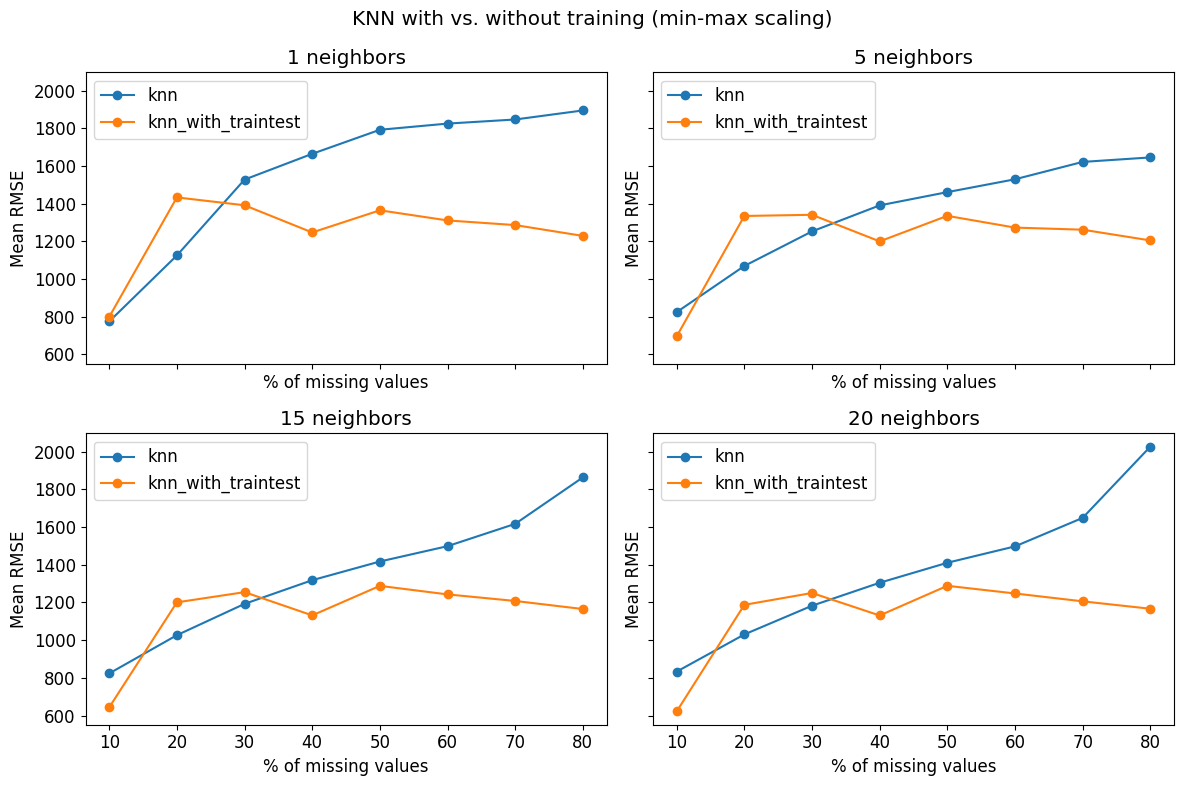

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

os.chdir("/home/ojsant/gradu/knn_results")
means = pd.read_csv("/home/ojsant/gradu/knn_results/20120127-183733.csv", header=[0, 1], index_col=[0, 1, 2])["rmse_mean"]
# stds = means.copy()

dfs = []
for i, csv in enumerate(os.listdir()):
    try:
        dfs.append(pd.read_csv(csv, header=[0, 1], index_col=[0, 1, 2])["rmse_mean"].to_numpy())
    except IsADirectoryError:
        continue

dfs = np.stack(dfs)
mean_rmses = np.nanmean(dfs, axis=0)
means.iloc[:] = mean_rmses
# std_rmses = np.std(dfs, axis=0, ddof=1)
# stds.iloc[:] = std_rmses
pcts = means.columns.astype(int)

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(12, 8), sharex=True, sharey=True)
fig.suptitle("KNN with vs. without training (min-max scaling)")
# Plot data
for i, n_neighbors in enumerate([1, 5, 15, 20]):
    ax = axs.ravel()[i]
    ax.plot(pcts, means.loc[("knn", "time", f"{n_neighbors}n")].values, "o-", label="knn")
    ax.plot(pcts, means.loc[("knn_with_traintest", "time", f"{n_neighbors}n")].values, "o-", label="knn_with_traintest")
    ax.legend(loc="upper left")
    ax.set_title(f"{n_neighbors} neighbors")
    ax.set_xlabel(r"% of missing values")
    ax.set_ylabel("Mean RMSE")
plt.tight_layout()

In [3]:
means

miss_percent                                        10          20  \
method             axis        n_neighbors                           
knn                time        1n           338.281033  993.883470   
                               5n           663.966091  815.414929   
                               15n          767.092866  850.791829   
                               20n          794.896493  897.450548   
                   pitch_angle 1n                  NaN         NaN   
                               5n                  NaN         NaN   
                               15n                 NaN         NaN   
                               20n                 NaN         NaN   
knn_with_traintest time        1n           312.784212  519.787008   
                               5n           286.736787  486.292301   
                               15n          315.244845  540.334191   
                               20n          341.642383  588.185699   
                   pitch_angle 1n                  NaN         NaN   
                               5n                  NaN         NaN   
                               15n                 NaN         NaN   
                               20n                 NaN         NaN   

miss_percent                                         30           40  \
method             axis        n_neighbors                             
knn                time        1n           1355.732331  1581.128968   
                               5n           1065.652367  1180.919591   
                               15n          1056.059392  1183.565324   
                               20n          1096.336172  1223.182848   
                   pitch_angle 1n                   NaN          NaN   
                               5n                   NaN          NaN   
                               15n                  NaN          NaN   
                               20n                  NaN          NaN   
knn_with_traintest time        1n            533.822298   545.937696   
                               5n            502.828797   501.927054   
                               15n           523.686989   518.539295   
                               20n           560.518435   548.931045   
                   pitch_angle 1n                   NaN          NaN   
                               5n                   NaN          NaN   
                               15n                  NaN          NaN   
                               20n                  NaN          NaN   

miss_percent                                         50           60  \
method             axis        n_neighbors                             
knn                time        1n           1966.340731  2179.646859   
                               5n           1341.989139  1520.589111   
                               15n          1387.218541  1606.661128   
                               20n          1424.261806  1649.531552   
                   pitch_angle 1n                   NaN          NaN   
                               5n                   NaN          NaN   
                               15n                  NaN          NaN   
                               20n                  NaN          NaN   
knn_with_traintest time        1n           1163.823929  1167.084736   
                               5n           1125.299315  1131.053023   
                               15n          1101.778758  1124.961108   
                               20n          1113.349413  1137.065965   
                   pitch_angle 1n                   NaN          NaN   
                               5n                   NaN          NaN   
                               15n                  NaN          NaN   
                               20n                  NaN          NaN   

miss_percent                                         70           80  
method             axis        n_neighbors                            
knn

### KNNImputer CV (with blocks)

In [ ]:
# Stacking of training cases for KNN imputer:
# concatenate 5 successive rows to one feature vector (5 * 180 = 900 features)
trains = []
for train in X_train:
    train_stacked = sliding_window_view(train, window_shape=(5,180)).reshape(-1, 5 * train.shape[1])   # ChatGPT solution
    trains.append(train_stacked)

X_train_stacked = np.vstack(trains)

In [ ]:
import logging
import sys
filehandler = logging.FileHandler(filename="./logs/cv_results.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

def form_test_matrices_blocks(model: KNNImputer, X_test: np.ndarray,
                       y_test: np.ndarray, n_samples=10, sample_loc=120) -> list:
    true = X_test[sample_loc:sample_loc+n_samples]
    test = y_test[sample_loc:sample_loc+n_samples]
    reduced = np.where(np.isfinite(test), true, np.nan)
    
    reduced_reshaped = reduced.reshape((2, 900))
    pred_full_reshaped = model.transform(reduced_reshaped)
    pred_full = pred_full_reshaped.reshape((10, 180))

    pred = np.where((np.isnan(reduced)
                    & np.isfinite(true)
                    & np.meshgrid(np.isfinite(reduced).any(axis=1), np.arange(0, reduced.shape[1]),
                                  indexing="ij")[0]),
                    pred_full, np.nan)
    target = np.where(np.isfinite(pred), true, np.nan)

    return [true, reduced, pred_full, pred, target]

# Model selection CV
neighbors = np.arange(0, 31, 5)
neighbors[0] = 1
#weights = ["distance", "uniform"]      10.2. no noticeable difference between these
n_splits = 3
n_events = 20
n_samples = 10
sample_loc = 120 # onset is located at two hours after start of the window

# Cross validation: shift train-test split by one 3 times (a sort of 3-fold CV),
# but test only 10 samples in each event (after onset) and only 20 events in each fold

for n in neighbors:
    imputer = KNNImputer(n_neighbors=n, weights="distance", keep_empty_features=True)
    
    for shift in range(n_splits):
        logging.info(f"KNN neighbors={n}, split {shift}")
        result_df = pd.DataFrame()
        (X_train, X_test, y_train, y_test,
        I_train, I_test, meta_train, meta_test) = make_train_test(hist_arr, reduced_hist_arr,
                                                                intensity_arr, metadata_arr,
                                                                n=n_splits, shift=shift)
        trains = []
        for train in X_train:
            train_stacked = sliding_window_view(train, window_shape=(5, train.shape[1])).reshape(-1, 5 * train.shape[1])   # ChatGPT solution
            trains.append(train_stacked)

        X_train_stacked = np.vstack(trains)
        imputer.fit(X_train_stacked)
        scores = []
        for j in range(20):
            res = form_test_matrices_blocks(imputer, X_test[j], y_test[j])
            # plot_results(model, res, "rmse", I_test[j], sc=wind, cov_sc=solo,
            #              save_path=plot_path / "knnimputer" / "crossvalidation" / f"knn_{n}_{w}_split_{shift}_results_{j}.png")
            
            # Score on n_samples samples during main event
            score = calculate_scores(res[3],
                                     res[4], "rmse")
            result_df = save_results(imputer, res, meta_test[j], "rmse", Path(f"./knn_{n}_split_{shift}_results.csv"))
            scores.append(score)
            logging.info(f"Score for test event {j}: {score}")

        clear_output()
        logging.info(f"KNN neighbors={n}: CV score on fold {shift}={np.mean(scores):.4f}")


02/10/2026 12:46:53 KNN neighbors=15, weights=uniform: CV score on fold 2=2407.7693


Event 20120122-030734 with 50 % MCAR missingness: results using method 'cubic2d' along pitch_angle axis
RMSE mean: 0.035
RMSE std: 0.001


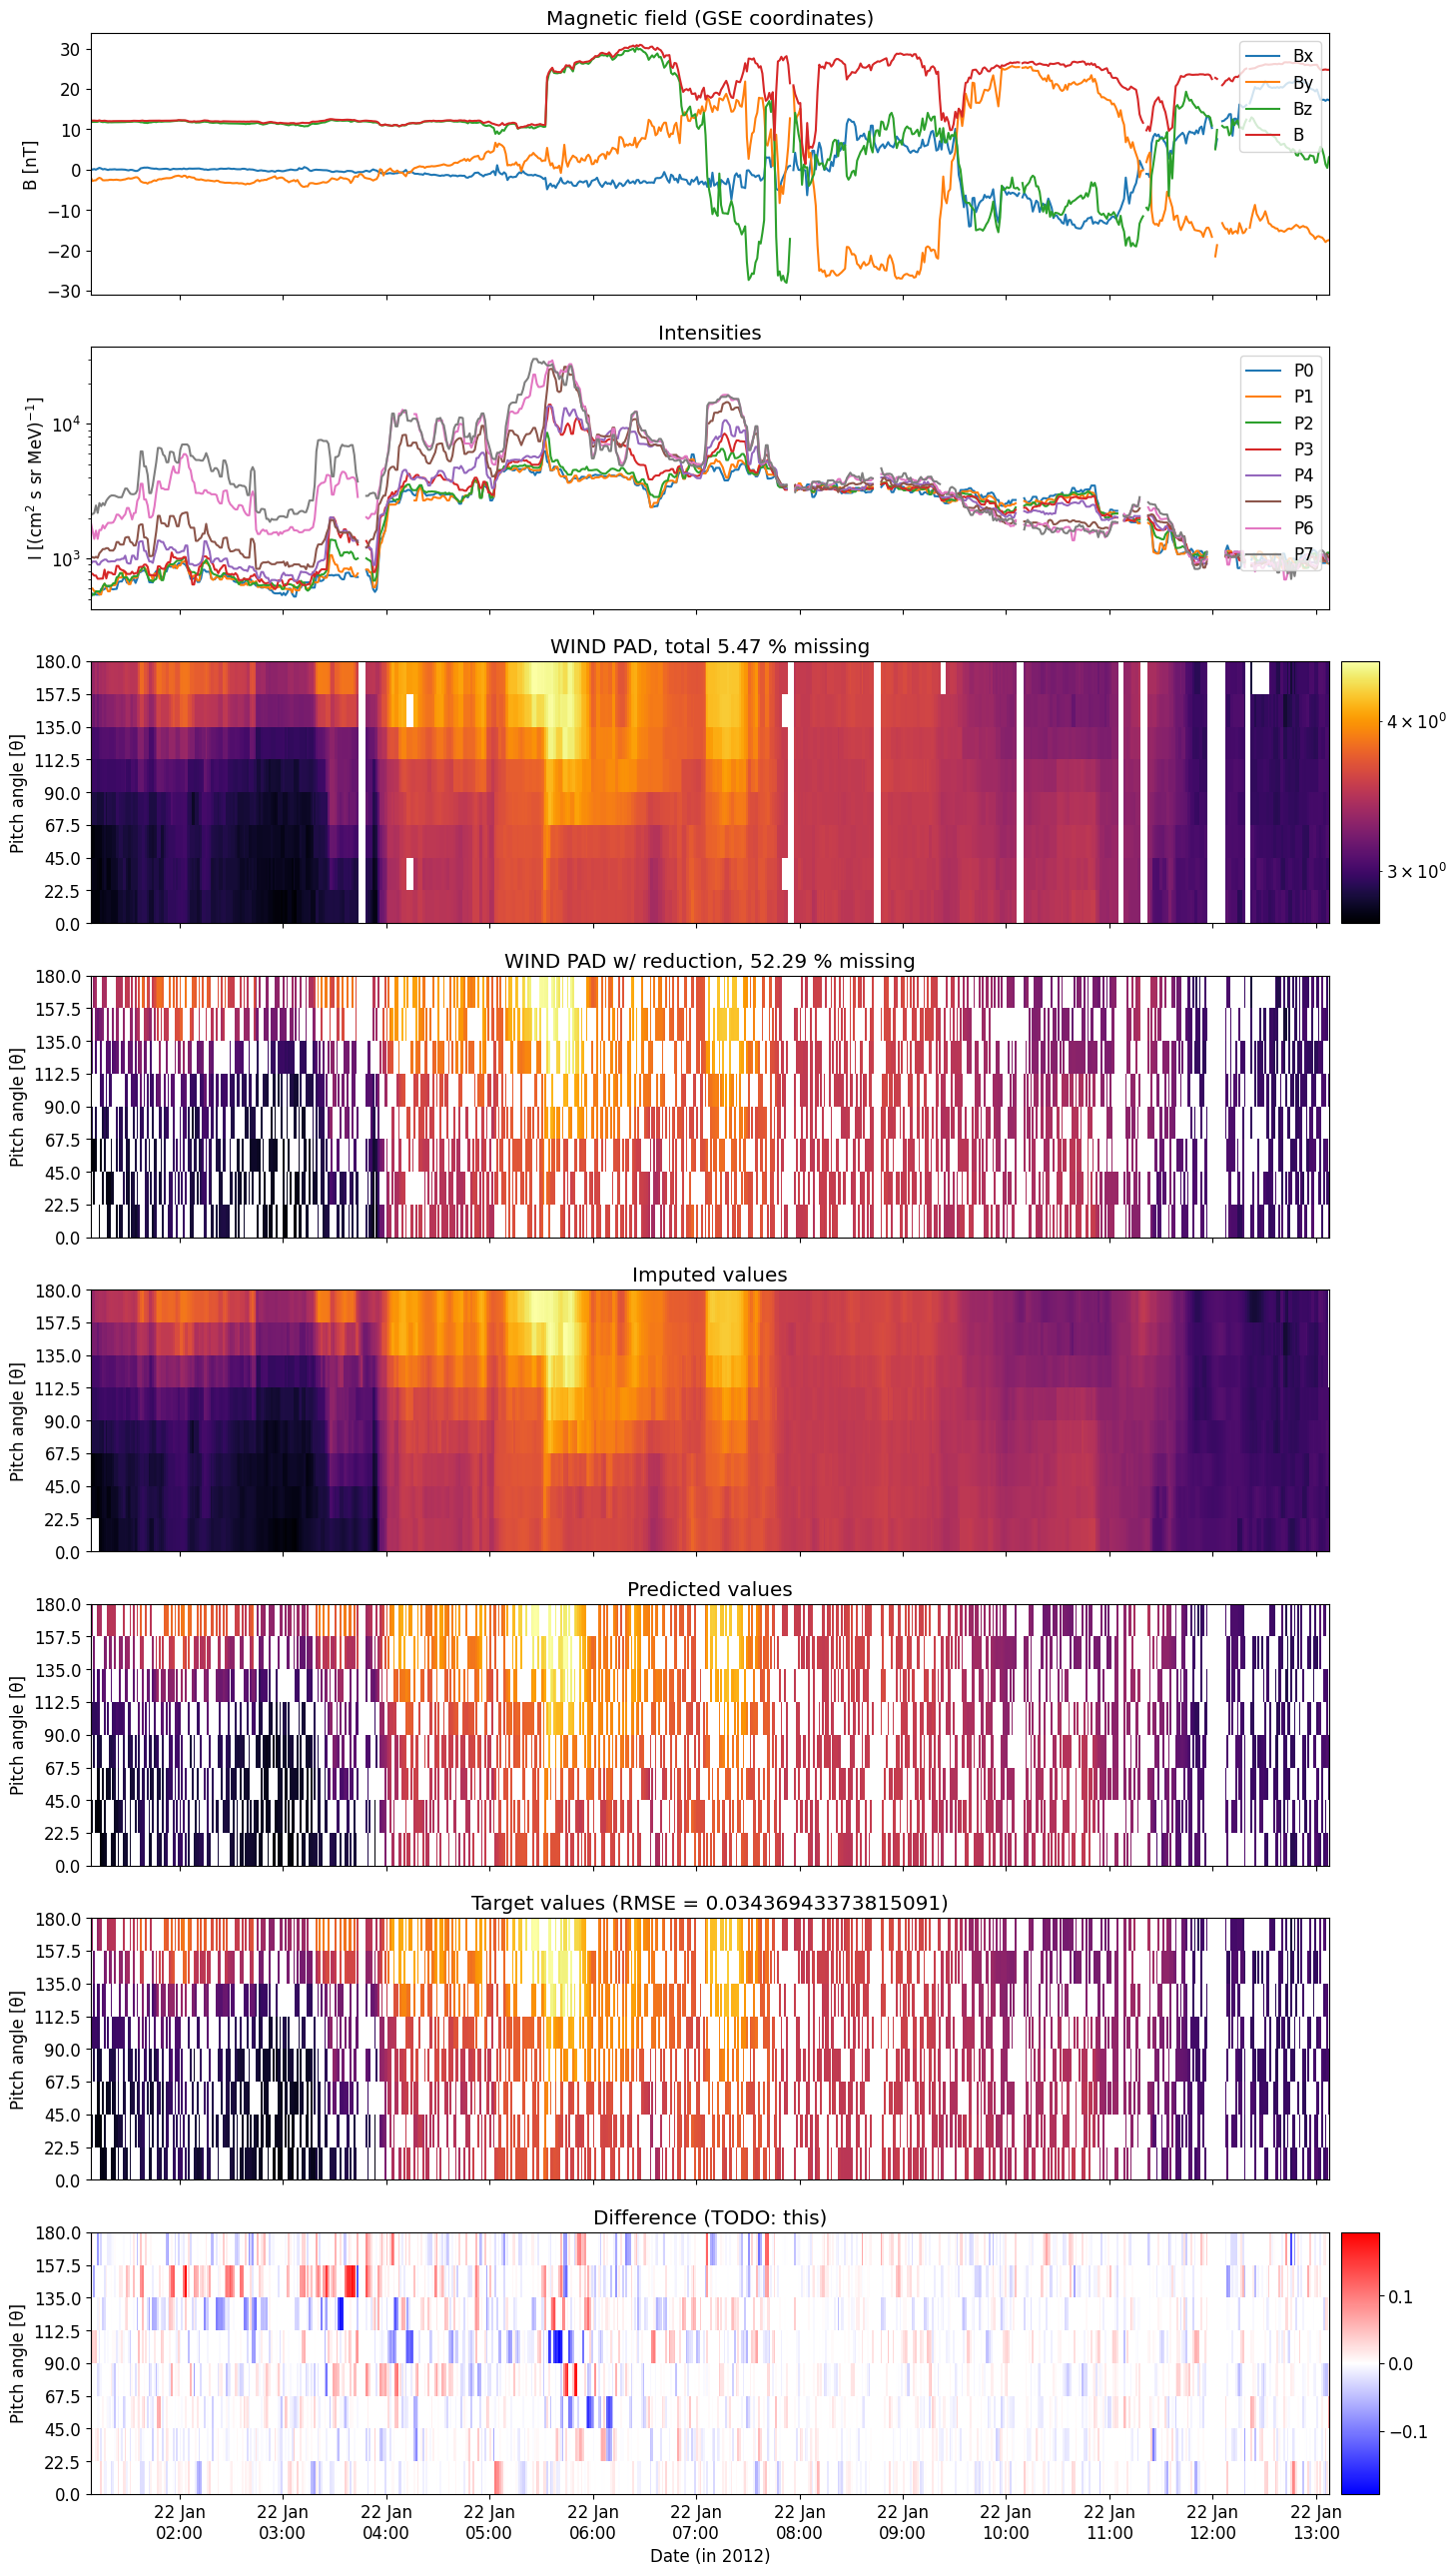

In [4]:
sc = WindConstants()
imputer = PADImputer(sc, method="cubic2d")
repeats = 100
miss_pct = 50
with h5py.File(file_path, 'r') as hdf:
    event_list = list(hdf.keys())
    event_key = event_list[1]
    imputer.run_analysis(event_key, miss_pct, repeats, scale="log", save_plot=False, file_path=file_path,
                         results_path=Path("."))

Clough-Tocher (piecewise cubic, curvature-minimizing) 2D interpolation (70 % MCAR)
Mean: 0.1984759526201289
Std: 0.014780895624314179


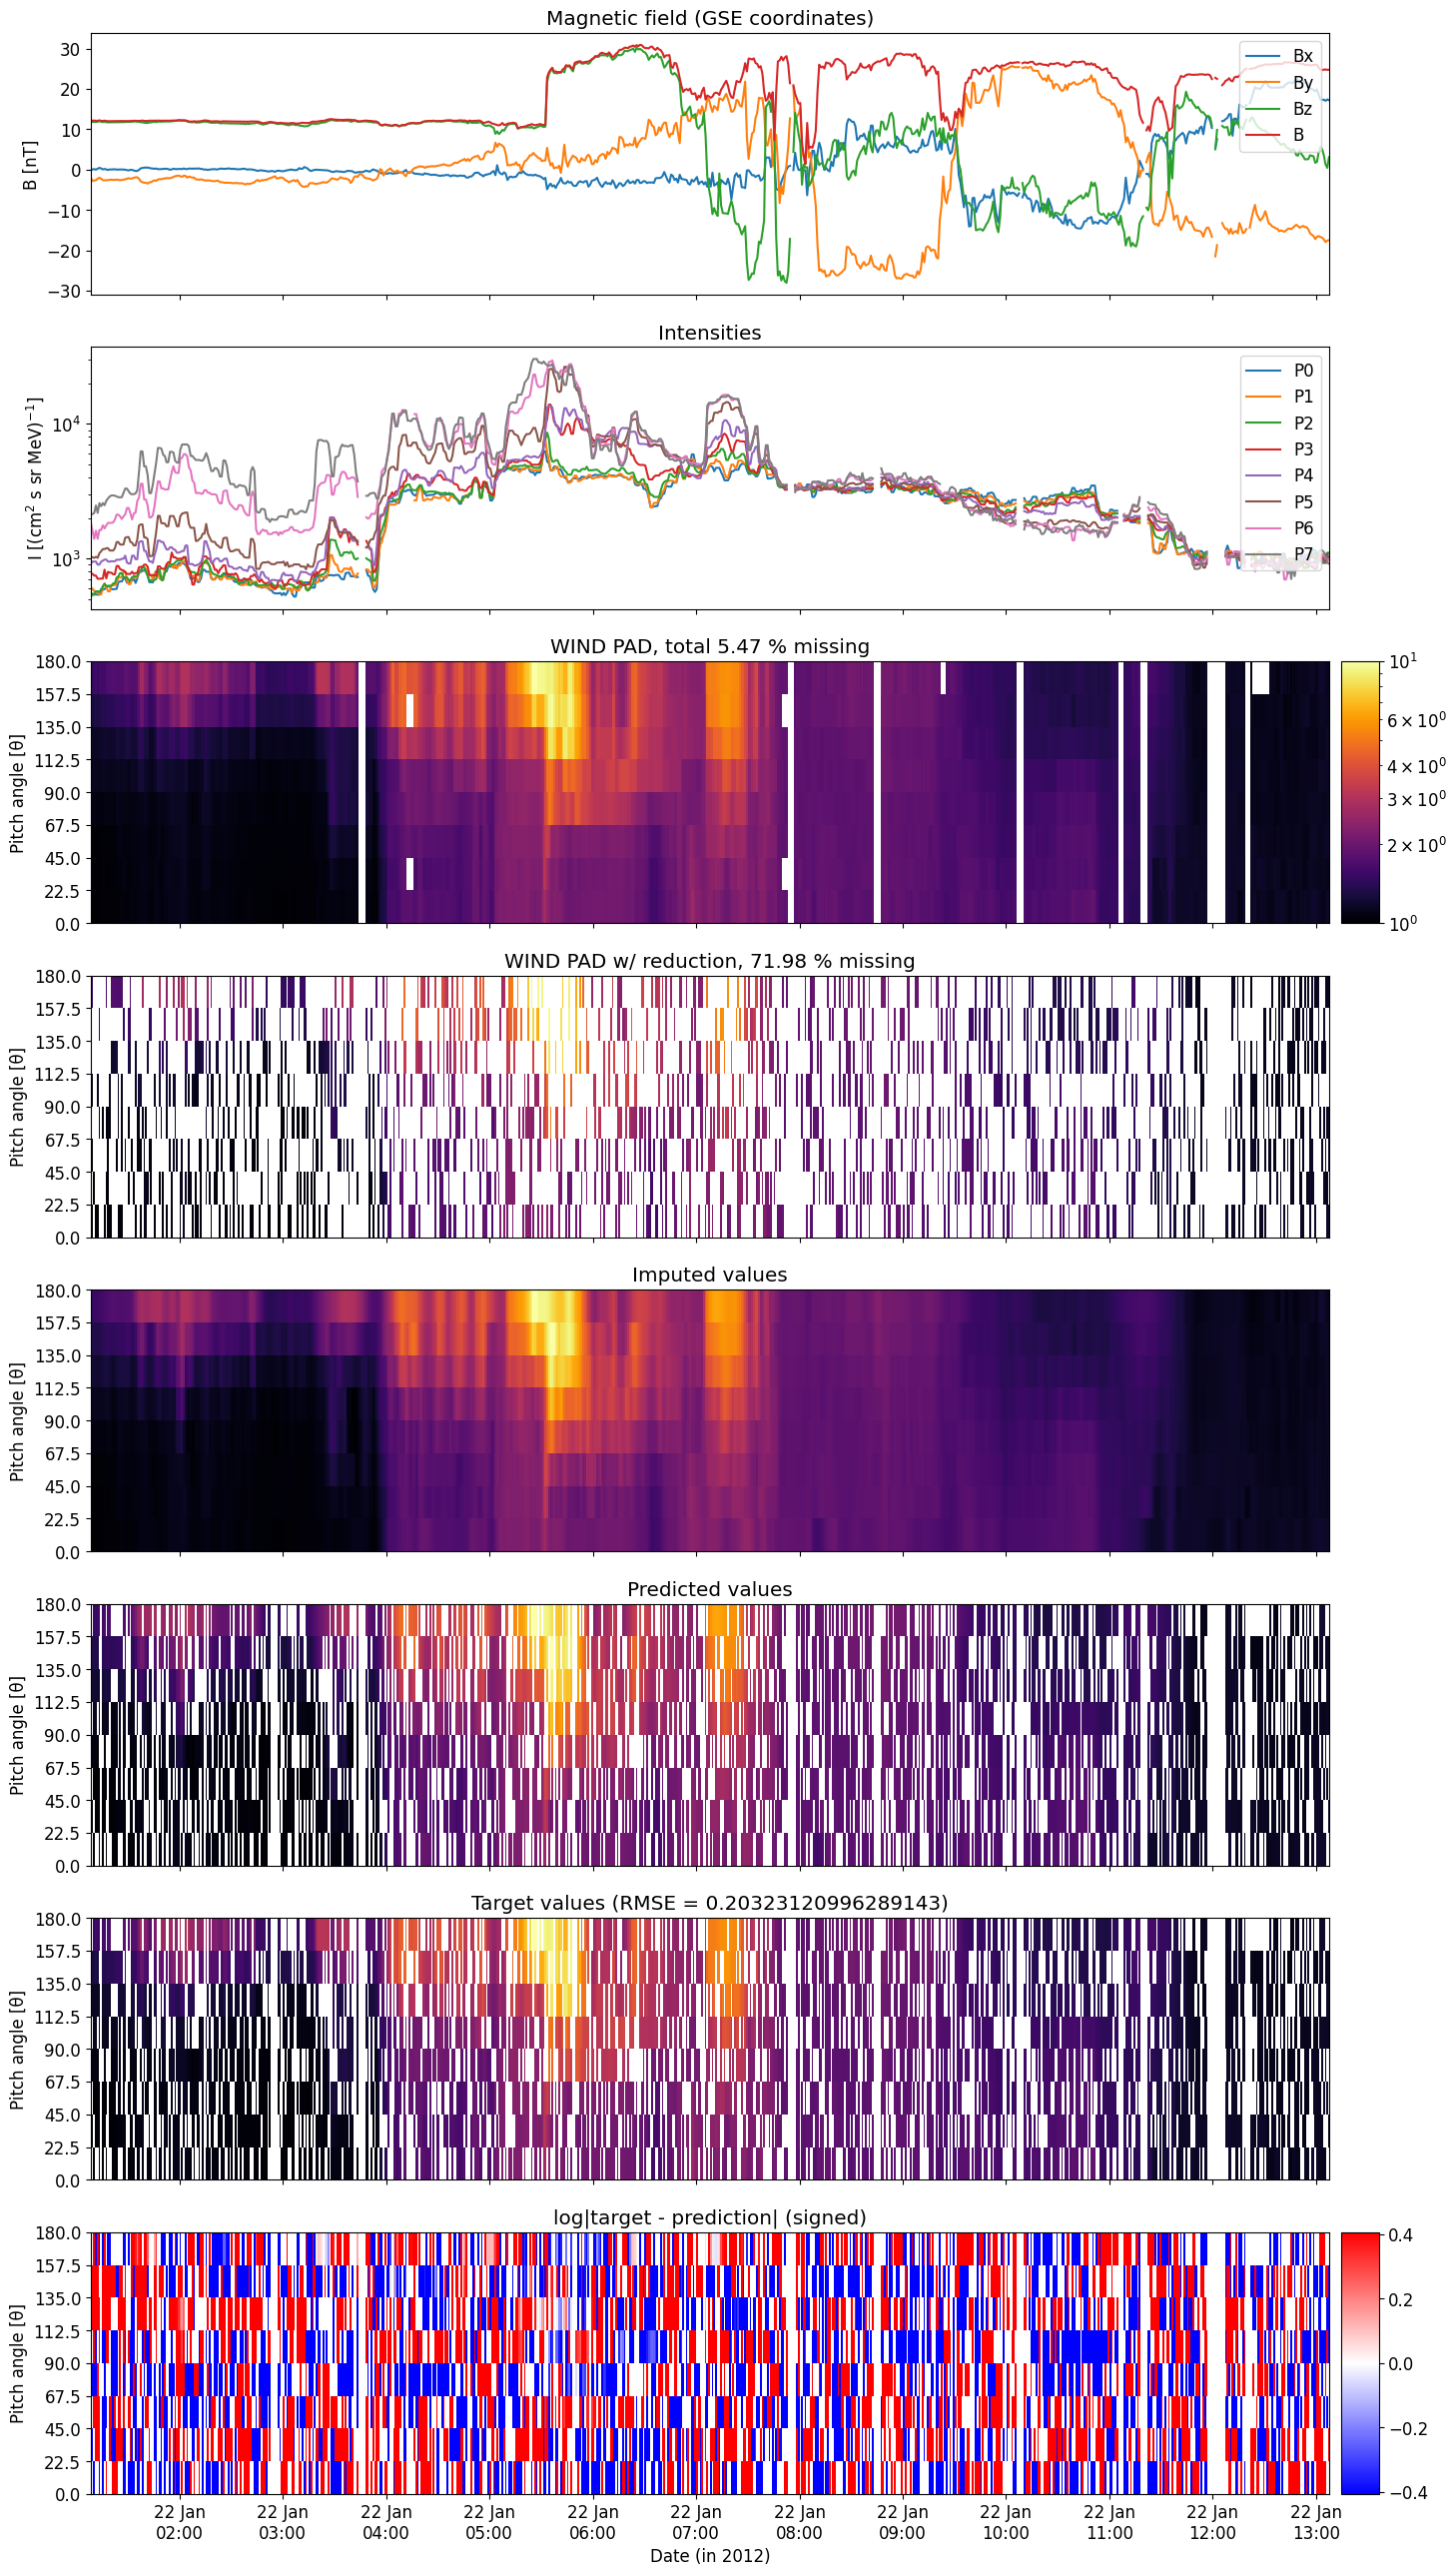

In [3]:
from aipad.pad_imputation import load_event_data, plot_results
from scipy.interpolate import griddata

def min_max_scale(a, interval=(0, 1)):
    return interval[0] + (interval[1] - interval[0])*(a - np.nanmin(a)) / (np.nanmax(a) - np.nanmin(a))

imputer = PADImputer(method="cubic", axis=0, cubic_dim=2)
repeats = 100
with h5py.File(file_path, 'r') as hdf:
    event_key = "20120122-030734"
    df = pd.read_csv(f"/home/ojsant/gradu/results/{event_key}.csv", header=0, index_col=[0, 1])
    event_data = load_event_data(hdf, event_key, wind)

    I_data = event_data["Intensity"]
    B_data = event_data["MagField"]
    cov_data = event_data["Coverage"]
    times = event_data["Intensity_attrs"]["Epoch"]

    I_min_max = min_max_scale(I_data.values, (1,10))

    X, Y, true = pad_histogram(wind, I_min_max, cov_data, 8)
    X, Y = np.meshgrid(np.arange(true.shape[0]), np.arange(true.shape[1]), indexing="ij")
    scores = []
    for i in range(repeats):
        reduced_cov, mask = induce_missingness(cov_data, 0.7)
        Xr, Yr, reduced = pad_histogram(wind, I_min_max, reduced_cov, 8)
        imputed = imputer.transform(reduced)
        target, pred = target_from_prediction(true, reduced, imputed)
        score = calculate_scores(target, pred, "rmse")
        scores.append(score)

    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    print("Clough-Tocher (piecewise cubic, curvature-minimizing) 2D interpolation (70 % MCAR)")
    print("Mean:", mean)
    print("Std:", std)
    pa = np.linspace(0.5*180/bins, (bins-0.5)*180/bins, bins)
    plot_results(pa, I_data, B_data, true, reduced, imputed, "rmse", wind, solo, save_plot=False)

In [1]:
imputer = PADImputer()
repeats = 100
with h5py.File(file_path, 'r') as hdf:
    
    df = pd.read_csv(f"./results/{event_key}.csv", header=[0, 1], index_col=[0, 1])
    
    event_data = load_event_data(hdf, event_key, wind)

    I_data = min_max_scale(event_data["Intensity"], (1, 10))
    B_data = event_data["MagField"]
    cov_data = event_data["Coverage"]
    times = event_data["Intensity_attrs"]["Epoch"]

    X, Y, true = pad_histogram(wind, I_data.values, cov_data, 8)
    imputer.method = "interp"
    imputer.axis = 0
    miss_percent = "70"
    scores = []
    
    for i in range(repeats):
        reduced_cov, mask = induce_missingness(cov_data, int(miss_percent) / 100)
        X, Y, reduced = pad_histogram(wind, I_data.values, reduced_cov, 8)
        imputed = imputer.fit_transform(reduced)
        target, pred = target_from_prediction(true, reduced, imputed)
        score = calculate_scores(target, pred, "rmse")
        scores.append(score)

    scores = np.array(scores)
    mean = scores.mean()
    std = scores.std(ddof=1)
    print("Linear 1D interpolation in time direction (70 % MCAR)")
    print("Mean:", mean)
    print("Std:", std)
    
    plot_results(Y[0], I_data, B_data, true, reduced, imputed, "rmse", wind, solo,
                 save_plot=False)

NameError: name 'PADImputer' is not defined

In [ ]:
from anisotropy.solo_methods import angle_between
from tqdm import tqdm

def calc_coverage(mag_data):
    opening = 40
    mag_vec = np.array([mag_data.Bx.to_numpy(), mag_data.By.to_numpy(), mag_data.Bz.to_numpy()])
    pointing_sun = np.array([-0.81915206, 0.57357645, 0.])
    pointing_asun = np.array([0.81915206, -0.57357645, 0.])
    pointing_north = np.array([0.30301532, 0.47649285, -0.8253098])
    pointing_south = np.array([-0.30301532, -0.47649285, 0.8253098])
    pointing_arr = np.vstack((pointing_sun, pointing_asun, pointing_north, pointing_south))

    pointing_sun = pointing_arr[0,:]
    pointing_asun = pointing_arr[1,:]
    pointing_north = pointing_arr[2,:]
    pointing_south = pointing_arr[3,:]
    pa_sun = np.ones(len(mag_data.Bx.to_numpy())) * np.nan
    pa_asun = np.ones(len(mag_data.Bx.to_numpy())) * np.nan
    pa_north = np.ones(len(mag_data.Bx.to_numpy())) * np.nan
    pa_south = np.ones(len(mag_data.Bx.to_numpy())) * np.nan

    for i in tqdm(range(len(mag_data.Bx.to_numpy()))):
        pa_sun[i] = np.rad2deg(angle_between(pointing_sun, mag_vec[:, i]))
        pa_asun[i] = np.rad2deg(angle_between(pointing_asun, mag_vec[:, i]))
        pa_north[i] = np.rad2deg(angle_between(pointing_north, mag_vec[:, i]))
        pa_south[i] = np.rad2deg(angle_between(pointing_south, mag_vec[:, i]))
    
    sun_min = pa_sun - opening/2
    sun_max = pa_sun + opening/2
    asun_min = pa_asun - opening/2
    asun_max = pa_asun + opening/2
    north_min = pa_north - opening/2
    north_max = pa_north + opening/2
    south_min = pa_south - opening/2
    south_max = pa_south + opening/2
    cov_sun = pd.DataFrame({'min': sun_min, 'center': pa_sun, 'max': sun_max}, index=mag_data.index)
    cov_asun = pd.DataFrame({'min': asun_min, 'center': pa_asun, 'max': asun_max}, index=mag_data.index)
    cov_north = pd.DataFrame({'min': north_min, 'center': pa_north, 'max': north_max}, index=mag_data.index)
    cov_south = pd.DataFrame({'min': south_min, 'center': pa_south, 'max': south_max}, index=mag_data.index)
    keys = [('sun'), ('asun'), ('north'), ('south')]
    coverage = pd.concat([cov_sun, cov_asun, cov_north, cov_south], keys=keys, axis=1)
    return coverage

cov = calc_coverage(B_data)
cov

100%|██████████| 1440/1440 [00:00<00:00, 9627.54it/s]


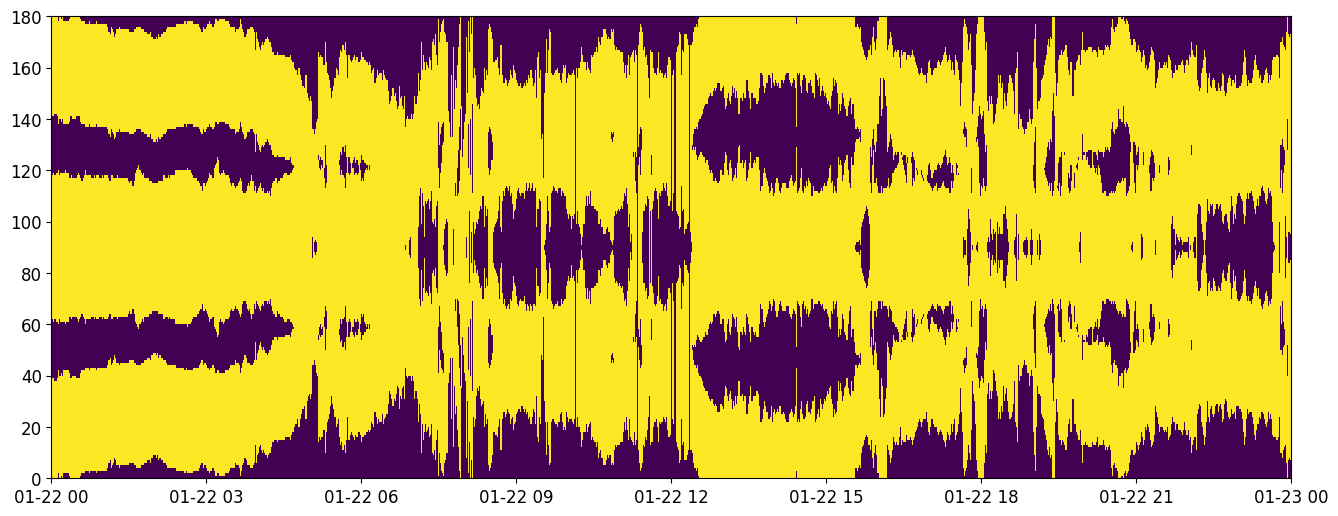

In [9]:
from aipad.pad_imputation import convert_to_bool_coverage

X, Y, wind_cov_bool = convert_to_bool_coverage(cov, solo, bins=180)
fig, ax = plt.subplots(figsize=(16,6))
ax.pcolormesh(X, Y, wind_cov_bool)

In [ ]:
imputer = PADImputer()
miss_pct = 10
index = pd.MultiIndex.from_product([method, ["time", "pitch_angle"]],
                                   names=["method", "axis"])
columns = pd.MultiIndex.from_product([["rmse_mean", "rmse_std"], [str(miss_pct)]],
                                    names=["stat", "miss_percent"])

df = pd.DataFrame(index=index, columns=columns)
df.loc[("mean", "time"), ("rmse_mean", str(20))] = 10
df.to_csv("test.csv")

In [28]:
df = pd.read_csv("test.csv", header=[0, 1], index_col=[0, 1])
df.loc[("mean2", "time"), ("rmse_mean", str(55))] = 10
df

stat                     rmse_mean rmse_std rmse_mean      
miss_percent                    10       10        20    55
method       axis                                          
mean         time              NaN      NaN      10.0   NaN
             pitch_angle       NaN      NaN       NaN   NaN
fill_average time              NaN      NaN       NaN   NaN
             pitch_angle       NaN      NaN       NaN   NaN
interp       time              NaN      NaN       NaN   NaN
             pitch_angle       NaN      NaN       NaN   NaN
knn          time              NaN      NaN       NaN   NaN
             pitch_angle       NaN      NaN       NaN   NaN
cubic        time              NaN      NaN       NaN   NaN
             pitch_angle       NaN      NaN       NaN   NaN
mean2        time              NaN      NaN       NaN  10.0

In [ ]:
%matplotlib widget

# importing required libraries
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt

# creating figure
fig = plt.figure()
ax = Axes3D(fig)

# creating the plot
rng = np.random.default_rng()
x = rng.random(10) - 0.5
y = rng.random(10) - 0.5
z = np.hypot(x, y)
X = np.linspace(min(x), max(x))
Y = np.linspace(min(y), max(y))
X, Y = np.meshgrid(X, Y)  # 2D grid for interpolation
interp = LinearNDInterpolator(list(zip(x, y)), z)
Z = interp(X, Y)
ax.plot_surface(X, Y, Z, cmap="viridis")
#ax.scatter(x, y, z)
#ax.legend()
#ax.axis("equal")

# setting title and labels
ax.set_title("3D plot")
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-axis')

# displaying the plot
plt.show()

SyntaxError: invalid syntax (3710665958.py, line 5)

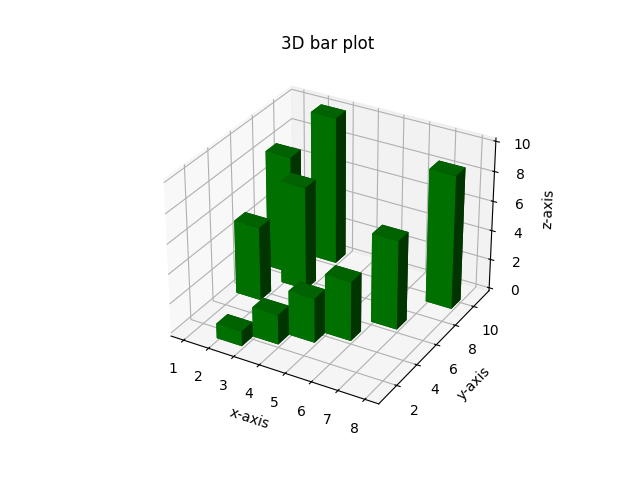

In [5]:
# creating 3d bar plot using matplotlib 
# in python

# to interact  with plot
%matplotlib widget

# importing required libraries
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# creating random dataset
xs = [2, 3, 4, 5, 1, 6, 2, 1, 7, 2]
ys = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
zs = np.zeros(10)
dx = np.ones(10)
dy = np.ones(10)
dz = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# creating figure
figg = plt.figure()
ax = figg.add_subplot(111, projection='3d')

# creating the plot
plot_geeks = ax.bar3d(xs, ys, zs, dx, 
                      dy, dz, color='green')

# setting title and labels
ax.set_title("3D bar plot")
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-axis')

# displaying the plot
plt.show()

In [7]:
df = pd.read_csv("/home/ojsant/gradu/knn_results/20121009-080740.csv", header=0, index_col=[0, 1])

In [12]:
df.loc[("knn", "20n"), "10"] = 5.0
df.loc[("knn", "20n"), "40"] = 69.0
df.loc[("knn", "17n"), "10"] = 420.0

In [14]:
df.loc[("knn", "17n"), "40"] = 67
df

10          20          50  \
method             n_neighbors                                       
knn                1n           179.360073  363.650210  691.149858   
                   5n           145.725818  280.546450  548.589906   
                   10n          155.034813  268.961143  548.285656   
                   15n          158.231800  280.732779  560.182296   
knn_with_traintest 1n           199.579826  256.830691  762.435543   
                   5n           193.727535  255.549605  626.496671   
                   10n          228.779039  288.929641  566.630936   
                   15n          271.122787  309.388706  571.223823   
knn                20n            5.000000         NaN         NaN   
                   17n          420.000000         NaN         NaN   

                                         80  ((knn, 20n), 10)    40  
method             n_neighbors                                       
knn                1n            764.817659               5.0   NaN  
                   5n            706.839286               5.0   NaN  
                   10n           818.592468               5.0   NaN  
                   15n           934.430125               5.0   NaN  
knn_with_traintest 1n           1118.284449               5.0   NaN  
                   5n           1042.523661               5.0   NaN  
                   10n          1040.353434               5.0   NaN  
                   15n          1035.445459               5.0   NaN  
knn                20n                  NaN               NaN  69.0  
                   17n                  NaN               NaN  67.0

In [4]:
x = np.array([10000, 20000, 30000, 40000])
print(np.log10(x))
print(10 ** np.log10(x))

[4.         4.30103    4.47712125 4.60205999]
[10000. 20000. 30000. 40000.]
